## Library

In [4]:
!pip install Sastrawi
!pip install indoNLP

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 3.1 MB/s eta 0:00:00


In [5]:
!pip install gensim
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.7 MB/s eta 0:00:00


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import nltk
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib
import matplotlib.gridspec as gridspec
import seaborn as sns
import sklearn
from platform import python_version
from wordcloud import WordCloud

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemover import StopWordRemover
from Sastrawi.Dictionary.ArrayDictionary import ArrayDictionary

from indoNLP.preprocessing import replace_slang
from indoNLP.preprocessing import remove_stopwords as indo_remove_stopwords
from indoNLP.preprocessing import replace_word_elongation as indo_replace_word_elongation
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('all')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downlo

True

In [7]:
import json
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB

In [8]:
import ast
from pprint import pprint

# Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

# Plotting tools
import pyLDAvis
import pyLDAvis.gensim
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

## Pengumpulan Data

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# Load Data
df = pd.read_csv('/content/drive/MyDrive/skripsi HUHU/4. Data Penelitian/Dataset/mbg_januari_sampai_oktober_2025.csv')
display(df)

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username;;;;;;;
0,1877134921455555002,Wed Jan 08 23:26:55 +0000 2025,0,Dengan MBG UMKM sebar suara agar anak-anak dap...,1877134921455555002,https://pbs.twimg.com/media/GgzsL0JaMAEuqk6.jpg,NaN,in,NaN,0,0,0,https://x.com/undefined/status/187713492145555...,1711942211200483328,;;;;;;;
1,1877134530437353914,Wed Jan 08 23:25:22 +0000 2025,0,Kehadiran UMKM buat MBG jadi solusi efektif me...,1877134530437353914,https://pbs.twimg.com/media/Ggzr5ZkaMAASzfx.jpg,NaN,in,NaN,0,0,0,https://x.com/undefined/status/187713453043735...,1701804750742986752,;;;;;;;
2,1877115246889849262,Wed Jan 08 22:08:44 +0000 2025,0,Dengan MBG UMKM membantu masyarakat mendapatka...,1877115246889849262,https://pbs.twimg.com/media/GgzaWfxaMAA8Dkf.jpg,NaN,in,NaN,0,0,0,https://x.com/undefined/status/187711524688984...,1693844411166404608,;;;;;;;
3,1877137580111569364,Wed Jan 08 23:37:29 +0000 2025,0,UMKM keroyokan banget di MBG demi masyarakat l...,1877137580111569364,https://pbs.twimg.com/media/GgzurX3aMAIQYRI.jpg,NaN,in,NaN,0,0,0,https://x.com/undefined/status/187713758011156...,1701441338712162304,;;;;;;;
4,1877134528675717178,Wed Jan 08 23:25:21 +0000 2025,0,Salut buat kemajuan MBG berkat keterlibatan pe...,1877134528675717178,https://pbs.twimg.com/media/Ggzr5xAaMAEQM_Z.jpg,NaN,in,NaN,0,0,0,https://x.com/undefined/status/187713452867571...,1698915447553597440,;;;;;;;
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9787,1975339828670832850,Mon Oct 06 23:18:09 +0000 2025,1,Buzzer MBG beraksi gaes,1975339828670832850,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/197533982867083...,154840456,;;;;;;;
9788,1975334697145405468,Mon Oct 06 22:57:46 +0000 2025,2,MBG SAAT INI BARU TAHAP SOSIALISASI KE DAERAH....,1975334697145405468,NaN,NaN,in,NaN,0,1,0,https://x.com/undefined/status/197533469714540...,986949263333572614,;;;;;;;
9789,1975343965126992036,Mon Oct 06 23:34:36 +0000 2025,0,Dalam upaya menjaga kualitas dan keamanan kons...,1975343965126992036,https://pbs.twimg.com/media/G2nU3YFbIAAJdQt.jpg,NaN,in,NaN,0,0,0,https://x.com/undefined/status/197534396512699...,1061919459022069760,;;;;;;;
9790,1975276880485060905,Mon Oct 06 19:08:01 +0000 2025,1,Penolakan MBG tidak bisa di lakukan tetapi bis...,1975276880485060905,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/197527688048506...,851669786,;;;;;;;


In [11]:
# Mengambil kolom yang relevan
print("Jumlah data sebelum hapus duplikat:", len(df))
df = df[['created_at', 'full_text']] # Hanya mengambil kolom created_at dan full_text
display(df)

Jumlah data sebelum hapus duplikat: 9792


,created_at,full_text
0,Wed Jan 08 23:26:55 +0000 2025,Dengan MBG UMKM sebar suara agar anak-anak dap...
1,Wed Jan 08 23:25:22 +0000 2025,Kehadiran UMKM buat MBG jadi solusi efektif me...
2,Wed Jan 08 22:08:44 +0000 2025,Dengan MBG UMKM membantu masyarakat mendapatka...
3,Wed Jan 08 23:37:29 +0000 2025,UMKM keroyokan banget di MBG demi masyarakat l...
4,Wed Jan 08 23:25:21 +0000 2025,Salut buat kemajuan MBG berkat keterlibatan pe...
...,...,...
9787,Mon Oct 06 23:18:09 +0000 2025,Buzzer MBG beraksi gaes
9788,Mon Oct 06 22:57:46 +0000 2025,MBG SAAT INI BARU TAHAP SOSIALISASI KE DAERAH....
9789,Mon Oct 06 23:34:36 +0000 2025,Dalam upaya menjaga kualitas dan keamanan kons...
9790,Mon Oct 06 19:08:01 +0000 2025,Penolakan MBG tidak bisa di lakukan tetapi bis...


## Eksplorasi Data

In [12]:
# Convert kolom created_at ke datetime (tujuan)
df['created_at'] = pd.to_datetime(df['created_at'])
display(df)

/tmp/ipykernel_638/887207620.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'])


,created_at,full_text
0,2025-01-08 23:26:55+00:00,Dengan MBG UMKM sebar suara agar anak-anak dap...
1,2025-01-08 23:25:22+00:00,Kehadiran UMKM buat MBG jadi solusi efektif me...
2,2025-01-08 22:08:44+00:00,Dengan MBG UMKM membantu masyarakat mendapatka...
3,2025-01-08 23:37:29+00:00,UMKM keroyokan banget di MBG demi masyarakat l...
4,2025-01-08 23:25:21+00:00,Salut buat kemajuan MBG berkat keterlibatan pe...
...,...,...
9787,2025-10-06 23:18:09+00:00,Buzzer MBG beraksi gaes
9788,2025-10-06 22:57:46+00:00,MBG SAAT INI BARU TAHAP SOSIALISASI KE DAERAH....
9789,2025-10-06 23:34:36+00:00,Dalam upaya menjaga kualitas dan keamanan kons...
9790,2025-10-06 19:08:01+00:00,Penolakan MBG tidak bisa di lakukan tetapi bis...


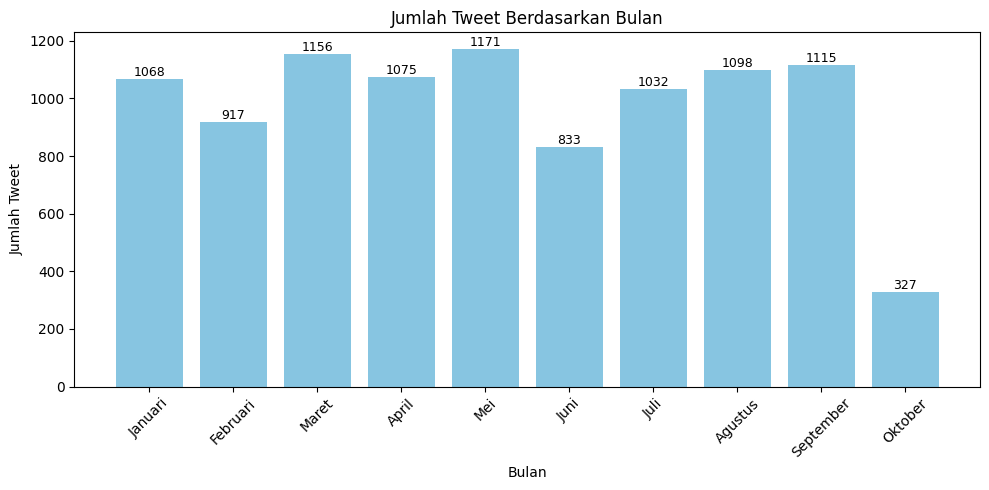

In [13]:
import matplotlib.pyplot as plt

# Ambil kolom bulan
df['month'] = df['created_at'].dt.month

month_order = [1,2,3,4,5,6,7,8,9,10]
month_labels = [
    "Januari", "Februari", "Maret", "April", "Mei",
    "Juni", "Juli", "Agustus", "September", "Oktober"
]

month_counts = df['month'].value_counts().reindex(month_order, fill_value=0)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    month_labels,
    month_counts,
    color='#87c5e1',
)

plt.title("Jumlah Tweet Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Tweet")
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Preprocessing Data

### **1. Case Folding**

In [14]:
df['clean_text'] = df['full_text'].str.lower()
display(df)

,created_at,full_text,month,clean_text
0,2025-01-08 23:26:55+00:00,Dengan MBG UMKM sebar suara agar anak-anak dap...,1,dengan mbg umkm sebar suara agar anak-anak dap...
1,2025-01-08 23:25:22+00:00,Kehadiran UMKM buat MBG jadi solusi efektif me...,1,kehadiran umkm buat mbg jadi solusi efektif me...
2,2025-01-08 22:08:44+00:00,Dengan MBG UMKM membantu masyarakat mendapatka...,1,dengan mbg umkm membantu masyarakat mendapatka...
3,2025-01-08 23:37:29+00:00,UMKM keroyokan banget di MBG demi masyarakat l...,1,umkm keroyokan banget di mbg demi masyarakat l...
4,2025-01-08 23:25:21+00:00,Salut buat kemajuan MBG berkat keterlibatan pe...,1,salut buat kemajuan mbg berkat keterlibatan pe...
...,...,...,...,...
9787,2025-10-06 23:18:09+00:00,Buzzer MBG beraksi gaes,10,buzzer mbg beraksi gaes
9788,2025-10-06 22:57:46+00:00,MBG SAAT INI BARU TAHAP SOSIALISASI KE DAERAH....,10,mbg saat ini baru tahap sosialisasi ke daerah....
9789,2025-10-06 23:34:36+00:00,Dalam upaya menjaga kualitas dan keamanan kons...,10,dalam upaya menjaga kualitas dan keamanan kons...
9790,2025-10-06 19:08:01+00:00,Penolakan MBG tidak bisa di lakukan tetapi bis...,10,penolakan mbg tidak bisa di lakukan tetapi bis...


### **3. Data Cleaning**

In [15]:
# List kata yang tidak relevan
unwanted_keywords = ['bgn', 'bgn tidur', 'bgn tdr', 'baru bgn', 'br bgn', 'muara', 'muara batang gadis', 'gadis', 'muara batang', 'batang gadis']

# Cari yang mengandung salah satu keyword (case-insensitive)
mask = df['full_text'].str.lower().str.contains('|'.join(unwanted_keywords))

# Hapus tweet tidak relevan berdasarkan keyword
df = df[~mask]
df.reset_index(drop=True, inplace=True)

df_filtered = df[mask]
display(df_filtered)

/tmp/ipykernel_638/3892541522.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df[mask]


,created_at,full_text,month,clean_text
105,2025-01-08 22:34:45+00:00,Koar koar makan bergizi gratis waktu pemilu da...,1,koar koar makan bergizi gratis waktu pemilu da...
114,2025-01-08 23:59:56+00:00,@OposisiCerdas Makan bergizi gratis seharusnya...,1,@oposisicerdas makan bergizi gratis seharusnya...
115,2025-01-08 22:36:25+00:00,Program Makan Bergizi Gratis Telah Dimulai di ...,1,program makan bergizi gratis telah dimulai di ...
118,2025-01-08 23:00:39+00:00,Respons Siswa SMA di Semarang soal Program Mak...,1,respons siswa sma di semarang soal program mak...
123,2025-01-08 23:49:27+00:00,Program Makan Bergizi Gratis dapat menjadi lom...,1,program makan bergizi gratis dapat menjadi lom...
...,...,...,...,...
8078,2025-10-06 23:59:43+00:00,Orang tua hebat! InsyaAllah selamat dari kerac...,10,orang tua hebat! insyaallah selamat dari kerac...
8079,2025-10-06 23:15:25+00:00,MBG adalah bagian dari cita-cita Pemerintah me...,10,mbg adalah bagian dari cita-cita pemerintah me...
8080,2025-10-06 23:35:31+00:00,Makan Bergizi Gratis Keutamaan Sedekah dan Kun...,10,makan bergizi gratis keutamaan sedekah dan kun...
8081,2025-10-06 21:47:29+00:00,@BosPurwa @prabowo @bang_dasco Semoga kedepann...,10,@bospurwa @prabowo @bang_dasco semoga kedepann...


In [16]:
# Hapus duplikat berdasarkan kolom tertentu
df = df.drop_duplicates(subset='full_text')

# reset index biar berurutan lagi
df = df.reset_index(drop=True)

print("Jumlah data sesudah hapus duplikat:", len(df))
display(df)

Jumlah data sesudah hapus duplikat: 8103


,created_at,full_text,month,clean_text
0,2025-01-08 23:26:55+00:00,Dengan MBG UMKM sebar suara agar anak-anak dap...,1,dengan mbg umkm sebar suara agar anak-anak dap...
1,2025-01-08 23:25:22+00:00,Kehadiran UMKM buat MBG jadi solusi efektif me...,1,kehadiran umkm buat mbg jadi solusi efektif me...
2,2025-01-08 22:08:44+00:00,Dengan MBG UMKM membantu masyarakat mendapatka...,1,dengan mbg umkm membantu masyarakat mendapatka...
3,2025-01-08 23:37:29+00:00,UMKM keroyokan banget di MBG demi masyarakat l...,1,umkm keroyokan banget di mbg demi masyarakat l...
4,2025-01-08 23:25:21+00:00,Salut buat kemajuan MBG berkat keterlibatan pe...,1,salut buat kemajuan mbg berkat keterlibatan pe...
...,...,...,...,...
8098,2025-10-06 19:09:34+00:00,@Julhan_Htbarat @MUIPusat Nah itu dia anak ker...,10,@julhan_htbarat @muipusat nah itu dia anak ker...
8099,2025-10-06 23:18:09+00:00,Buzzer MBG beraksi gaes,10,buzzer mbg beraksi gaes
8100,2025-10-06 23:34:36+00:00,Dalam upaya menjaga kualitas dan keamanan kons...,10,dalam upaya menjaga kualitas dan keamanan kons...
8101,2025-10-06 19:08:01+00:00,Penolakan MBG tidak bisa di lakukan tetapi bis...,10,penolakan mbg tidak bisa di lakukan tetapi bis...


In [17]:
# === Fungsi Cleaning / Removing Noise ===
def clean_text(text):
    text = str(text)
    text = text.lower()  # ubah ke huruf kecil
    text = re.sub(r'http\S+', '', text)  # hapus link
    text = re.sub(r'@\w+', '', text)  # hapus mention
    text = re.sub(r'#\w+', '', text)  # hapus hashtag
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # hapus karakter non-huruf
    text = re.sub(r'\s+', ' ', text).strip()  # hapus spasi berlebih
    return text

df['clean_text'] = df['full_text'].apply(clean_text)
display(df)

,created_at,full_text,month,clean_text
0,2025-01-08 23:26:55+00:00,Dengan MBG UMKM sebar suara agar anak-anak dap...,1,dengan mbg umkm sebar suara agar anak anak dap...
1,2025-01-08 23:25:22+00:00,Kehadiran UMKM buat MBG jadi solusi efektif me...,1,kehadiran umkm buat mbg jadi solusi efektif me...
2,2025-01-08 22:08:44+00:00,Dengan MBG UMKM membantu masyarakat mendapatka...,1,dengan mbg umkm membantu masyarakat mendapatka...
3,2025-01-08 23:37:29+00:00,UMKM keroyokan banget di MBG demi masyarakat l...,1,umkm keroyokan banget di mbg demi masyarakat l...
4,2025-01-08 23:25:21+00:00,Salut buat kemajuan MBG berkat keterlibatan pe...,1,salut buat kemajuan mbg berkat keterlibatan pe...
...,...,...,...,...
8098,2025-10-06 19:09:34+00:00,@Julhan_Htbarat @MUIPusat Nah itu dia anak ker...,10,nah itu dia anak keracunan mbg pada diem kasus...
8099,2025-10-06 23:18:09+00:00,Buzzer MBG beraksi gaes,10,buzzer mbg beraksi gaes
8100,2025-10-06 23:34:36+00:00,Dalam upaya menjaga kualitas dan keamanan kons...,10,dalam upaya menjaga kualitas dan keamanan kons...
8101,2025-10-06 19:08:01+00:00,Penolakan MBG tidak bisa di lakukan tetapi bis...,10,penolakan mbg tidak bisa di lakukan tetapi bis...


### **4. Normalization**

In [18]:
# Contoh custom slang → formal
custom_slang_dict = {
    'mbg': 'makan bergizi gratis',
    'nggak': 'tidak',
    'gak': 'tidak',
    'ga': 'tidak',
    'enggak': 'tidak',
    'tdk': 'tidak',
    'g': 'tidak',
    'engga': 'tidak'
}

# Fungsi untuk replace custom slang
def replace_custom_slang(text, slang_dict):
    pattern = re.compile(r'\b(' + '|'.join(re.escape(k) for k in slang_dict.keys()) + r')\b')
    return pattern.sub(lambda x: slang_dict[x.group()], text)

# Full slang normalization pipeline
def full_slang_replacement(text):
    text = replace_custom_slang(text, custom_slang_dict)  # Custom slang replacement
    text = replace_slang(text)  # IndoNLP slang replacement
    return text

# Terapkan ke kolom
df['clean_text_norm'] = df['clean_text'].apply(full_slang_replacement)

# Set opsi tampilan agar teks panjang ditampilkan penuh
pd.set_option('display.max_colwidth', None)

df['clean_text_norm'] = df['clean_text_norm'].apply(indo_replace_word_elongation)
display(df)

,created_at,full_text,month,clean_text,clean_text_norm
0,2025-01-08 23:26:55+00:00,Dengan MBG UMKM sebar suara agar anak-anak dapatkan manfaat seutuhnya #UMKMDukungMBG https://t.co/5DFTlg6UDK,1,dengan mbg umkm sebar suara agar anak anak dapatkan manfaat seutuhnya,dengan makan bergizi gratis umkm sebar suara agar anak anak dapatkan manfaat seutuhnya
1,2025-01-08 23:25:22+00:00,Kehadiran UMKM buat MBG jadi solusi efektif membuat sehat #UMKMDukungMBG https://t.co/HDHUt3Essy,1,kehadiran umkm buat mbg jadi solusi efektif membuat sehat,kehadiran umkm buat makan bergizi gratis jadi solusi efektif membuat sehat
2,2025-01-08 22:08:44+00:00,Dengan MBG UMKM membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan #UMKMDukungMBG https://t.co/FUciDjcfon,1,dengan mbg umkm membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan,dengan makan bergizi gratis umkm membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan
3,2025-01-08 23:37:29+00:00,UMKM keroyokan banget di MBG demi masyarakat lebih sehat dan terjangkau #UMKMDukungMBG https://t.co/VwjRil59uT,1,umkm keroyokan banget di mbg demi masyarakat lebih sehat dan terjangkau,umkm keroyokan banget di makan bergizi gratis demi masyarakat lebih sehat dan terjangkau
4,2025-01-08 23:25:21+00:00,Salut buat kemajuan MBG berkat keterlibatan penuh UMKM yang turut andil #UMKMDukungMBG https://t.co/mWf9If2xaQ,1,salut buat kemajuan mbg berkat keterlibatan penuh umkm yang turut andil,salut buat kemajuan makan bergizi gratis berkat keterlibatan penuh umkm yang turut andil
...,...,...,...,...,...
8098,2025-10-06 19:09:34+00:00,@Julhan_Htbarat @MUIPusat Nah itu dia anak keracunan MBG pada diem kasus ini juga pada diem eh giliran ads kerja dikomentari mana komentarnya gak bermutu lagi. Eh btw ente setuju gak kalau ormas itu dibubarin? Gak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pake cuan lo,10,nah itu dia anak keracunan mbg pada diem kasus ini juga pada diem eh giliran ads kerja dikomentari mana komentarnya gak bermutu lagi eh btw ente setuju gak kalau ormas itu dibubarin gak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pake cuan lo,nah itu dia anak keracunan makan bergizi gratis pada diam kasus ini juga pada diam eh giliran ads kerja dikomentari mana komentarnya tidak bermutu lagi eh btw ente setuju tidak kalau ormas itu dibubarin tidak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pakai cuan lo
8099,2025-10-06 23:18:09+00:00,Buzzer MBG beraksi gaes,10,buzzer mbg beraksi gaes,buzzer makan bergizi gratis beraksi gaes
8100,2025-10-06 23:34:36+00:00,Dalam upaya menjaga kualitas dan keamanan konsumsi masyarakat Bhabinkamtibmas Kelurahan Bantar Gebang Aiptu Zainal Musyarifin melaksanakan kegiatan pengecekan menu makanan MBG di Dapur MBG Bangun Persada SPPG Bantargebang Selasa(7/10/25). https://t.co/KwbAZzsyAV,10,dalam upaya menjaga kualitas dan keamanan konsumsi masyarakat bhabinkamtibmas kelurahan bantar gebang aiptu zainal musyarifin melaksanakan kegiatan pengecekan menu makanan mbg di dapur mbg bangun persada sppg bantargebang selasa,dalam upaya menjaga kualitas dan keamanan konsumsi masyarakat bhabinkamtibmas kelurahan bantar gebang aiptu zainal musyarifin melaksanakan kegiatan pengecekan menu makanan makan bergizi gratis di dapur makan bergizi gratis bangun persada sppg bantargebang selasa
8101,2025-10-06 19:08:01+00:00,Penolakan MBG tidak bisa di lakukan tetapi bisa di berikan pengertian terhadap murid di sekolah. By : guru bimbel,10,penolakan mbg tidak bisa di lakukan tetapi bisa di berikan pengertian terhadap murid di sekolah by guru bimbel,penolakan makan bergizi gratis tidak bisa di lakukan tetapi bisa di berikan pengertian terhadap murid di sekolah by guru bimbel


### **5. Tokenization**

In [19]:
df['tokens'] = df['clean_text_norm'].apply(word_tokenize)
display(df)

,created_at,full_text,month,clean_text,clean_text_norm,tokens
0,2025-01-08 23:26:55+00:00,Dengan MBG UMKM sebar suara agar anak-anak dapatkan manfaat seutuhnya #UMKMDukungMBG https://t.co/5DFTlg6UDK,1,dengan mbg umkm sebar suara agar anak anak dapatkan manfaat seutuhnya,dengan makan bergizi gratis umkm sebar suara agar anak anak dapatkan manfaat seutuhnya,"[dengan, makan, bergizi, gratis, umkm, sebar, suara, agar, anak, anak, dapatkan, manfaat, seutuhnya]"
1,2025-01-08 23:25:22+00:00,Kehadiran UMKM buat MBG jadi solusi efektif membuat sehat #UMKMDukungMBG https://t.co/HDHUt3Essy,1,kehadiran umkm buat mbg jadi solusi efektif membuat sehat,kehadiran umkm buat makan bergizi gratis jadi solusi efektif membuat sehat,"[kehadiran, umkm, buat, makan, bergizi, gratis, jadi, solusi, efektif, membuat, sehat]"
2,2025-01-08 22:08:44+00:00,Dengan MBG UMKM membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan #UMKMDukungMBG https://t.co/FUciDjcfon,1,dengan mbg umkm membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan,dengan makan bergizi gratis umkm membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan,"[dengan, makan, bergizi, gratis, umkm, membantu, masyarakat, mendapatkan, akses, pangan, berkualitas, dan, terus, menjaga, kesehatan]"
3,2025-01-08 23:37:29+00:00,UMKM keroyokan banget di MBG demi masyarakat lebih sehat dan terjangkau #UMKMDukungMBG https://t.co/VwjRil59uT,1,umkm keroyokan banget di mbg demi masyarakat lebih sehat dan terjangkau,umkm keroyokan banget di makan bergizi gratis demi masyarakat lebih sehat dan terjangkau,"[umkm, keroyokan, banget, di, makan, bergizi, gratis, demi, masyarakat, lebih, sehat, dan, terjangkau]"
4,2025-01-08 23:25:21+00:00,Salut buat kemajuan MBG berkat keterlibatan penuh UMKM yang turut andil #UMKMDukungMBG https://t.co/mWf9If2xaQ,1,salut buat kemajuan mbg berkat keterlibatan penuh umkm yang turut andil,salut buat kemajuan makan bergizi gratis berkat keterlibatan penuh umkm yang turut andil,"[salut, buat, kemajuan, makan, bergizi, gratis, berkat, keterlibatan, penuh, umkm, yang, turut, andil]"
...,...,...,...,...,...,...
8098,2025-10-06 19:09:34+00:00,@Julhan_Htbarat @MUIPusat Nah itu dia anak keracunan MBG pada diem kasus ini juga pada diem eh giliran ads kerja dikomentari mana komentarnya gak bermutu lagi. Eh btw ente setuju gak kalau ormas itu dibubarin? Gak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pake cuan lo,10,nah itu dia anak keracunan mbg pada diem kasus ini juga pada diem eh giliran ads kerja dikomentari mana komentarnya gak bermutu lagi eh btw ente setuju gak kalau ormas itu dibubarin gak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pake cuan lo,nah itu dia anak keracunan makan bergizi gratis pada diam kasus ini juga pada diam eh giliran ads kerja dikomentari mana komentarnya tidak bermutu lagi eh btw ente setuju tidak kalau ormas itu dibubarin tidak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pakai cuan lo,"[nah, itu, dia, anak, keracunan, makan, bergizi, gratis, pada, diam, kasus, ini, juga, pada, diam, eh, giliran, ads, kerja, dikomentari, mana, komentarnya, tidak, bermutu, lagi, eh, btw, ente, setuju, tidak, kalau, ormas, itu, dibubarin, tidak, ada, manfaatnya, sama, sekali, kecuali, urusan, sertifikasi, halal, dan, itu, pakai, cuan, lo]"
8099,2025-10-06 23:18:09+00:00,Buzzer MBG beraksi gaes,10,buzzer mbg beraksi gaes,buzzer makan bergizi gratis beraksi gaes,"[buzzer, makan, bergizi, gratis, beraksi, gaes]"
8100,2025-10-06 23:34:36+00:00,Dalam upaya menjaga kualitas dan keamanan konsumsi masyarakat Bhabinkamtibmas Kelurahan Bantar Gebang Aiptu Zainal Musyarifin melaksanakan kegiatan pengecekan menu makanan MBG di Dapur MBG Bangun Persada SPPG Bantargebang Selasa(7/10/25). https://t.co/KwbAZzsyAV,10,dalam upaya menjaga kualitas dan keamanan konsumsi masyarakat bhabinkamtibmas kelurahan bantar gebang aiptu zainal musyarifi

### **6. Stopword Removal**

In [20]:
# Custom Sastrawi stopword list (tidak di-exclude)
default_factory = StopWordRemoverFactory()
default_stopwords = default_factory.get_stop_words()
filtered_stopwords = [word for word in default_stopwords if word != 'tidak']
dictionary = ArrayDictionary(filtered_stopwords)
sastrawi_remover = StopWordRemover(dictionary)

# Custom stopwords (kata yang ingin DIHAPUS)
custom_stopwords = {
    'yg','aja','jd','jadi','nya','ny','lu', 'lo','gue','gwe','gak','ga','gk','enggak',
    'sih','mah','nih','deh','dong','lah','kan','oke','ok','udah','udh',
    'banget','bgt','kalo','kalau','dl','dulu','br','baru','bikin',
    'tak','penuh','biar','mau','lebih','bukan','semua','krn','cuma','ajar','tetap',
    'dgn','sama','tau','si','utk','kok','hingga','aku','lalu','klo','gw','malah',
    'banyak','bgtt','kayak','gitu','iya','langsung','nah','pun','terus','lagi',
    'memang','kayaknya','apalagi','padahal','sebenarnya','apa','toh','agar','supaya',
    'hal','dalam','eh','tp','dr','orang','org','sedikit','besar','kecil',
    'satu','dua','tiga','dll','lain','cuman',
}

# Fungsi untuk menghapus custom stopwords
def remove_custom_stopwords(text, stopwords_set):
    words = text.split()
    filtered_words = [word for word in words if word not in stopwords_set]
    return ' '.join(filtered_words)

# Full cleaning pipeline
def stopword_removal(text):
    # Step 1: IndoNLP stopword removal
    text = indo_remove_stopwords(text)
    # Step 2: Sastrawi stopword removal (tanpa menghapus "tidak")
    text = sastrawi_remover.remove(text)
    # Step 3: Custom stopword removal
    text = remove_custom_stopwords(text, custom_stopwords)

    return text

# Terapkan pipeline ke dataframe
df['tokens_no_stop'] = df['tokens'].apply(lambda x: stopword_removal(' '.join(x)).split())
display(df)

,created_at,full_text,month,clean_text,clean_text_norm,tokens,tokens_no_stop
0,2025-01-08 23:26:55+00:00,Dengan MBG UMKM sebar suara agar anak-anak dapatkan manfaat seutuhnya #UMKMDukungMBG https://t.co/5DFTlg6UDK,1,dengan mbg umkm sebar suara agar anak anak dapatkan manfaat seutuhnya,dengan makan bergizi gratis umkm sebar suara agar anak anak dapatkan manfaat seutuhnya,"[dengan, makan, bergizi, gratis, umkm, sebar, suara, agar, anak, anak, dapatkan, manfaat, seutuhnya]","[makan, bergizi, gratis, umkm, sebar, suara, anak, anak, dapatkan, manfaat, seutuhnya]"
1,2025-01-08 23:25:22+00:00,Kehadiran UMKM buat MBG jadi solusi efektif membuat sehat #UMKMDukungMBG https://t.co/HDHUt3Essy,1,kehadiran umkm buat mbg jadi solusi efektif membuat sehat,kehadiran umkm buat makan bergizi gratis jadi solusi efektif membuat sehat,"[kehadiran, umkm, buat, makan, bergizi, gratis, jadi, solusi, efektif, membuat, sehat]","[kehadiran, umkm, makan, bergizi, gratis, solusi, efektif, sehat]"
2,2025-01-08 22:08:44+00:00,Dengan MBG UMKM membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan #UMKMDukungMBG https://t.co/FUciDjcfon,1,dengan mbg umkm membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan,dengan makan bergizi gratis umkm membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan,"[dengan, makan, bergizi, gratis, umkm, membantu, masyarakat, mendapatkan, akses, pangan, berkualitas, dan, terus, menjaga, kesehatan]","[makan, bergizi, gratis, umkm, membantu, masyarakat, akses, pangan, berkualitas, menjaga, kesehatan]"
3,2025-01-08 23:37:29+00:00,UMKM keroyokan banget di MBG demi masyarakat lebih sehat dan terjangkau #UMKMDukungMBG https://t.co/VwjRil59uT,1,umkm keroyokan banget di mbg demi masyarakat lebih sehat dan terjangkau,umkm keroyokan banget di makan bergizi gratis demi masyarakat lebih sehat dan terjangkau,"[umkm, keroyokan, banget, di, makan, bergizi, gratis, demi, masyarakat, lebih, sehat, dan, terjangkau]","[umkm, keroyokan, makan, bergizi, gratis, masyarakat, sehat, terjangkau]"
4,2025-01-08 23:25:21+00:00,Salut buat kemajuan MBG berkat keterlibatan penuh UMKM yang turut andil #UMKMDukungMBG https://t.co/mWf9If2xaQ,1,salut buat kemajuan mbg berkat keterlibatan penuh umkm yang turut andil,salut buat kemajuan makan bergizi gratis berkat keterlibatan penuh umkm yang turut andil,"[salut, buat, kemajuan, makan, bergizi, gratis, berkat, keterlibatan, penuh, umkm, yang, turut, andil]","[salut, kemajuan, makan, bergizi, gratis, berkat, keterlibatan, umkm, andil]"
...,...,...,...,...,...,...,...
8098,2025-10-06 19:09:34+00:00,@Julhan_Htbarat @MUIPusat Nah itu dia anak keracunan MBG pada diem kasus ini juga pada diem eh giliran ads kerja dikomentari mana komentarnya gak bermutu lagi. Eh btw ente setuju gak kalau ormas itu dibubarin? Gak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pake cuan lo,10,nah itu dia anak keracunan mbg pada diem kasus ini juga pada diem eh giliran ads kerja dikomentari mana komentarnya gak bermutu lagi eh btw ente setuju gak kalau ormas itu dibubarin gak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pake cuan lo,nah itu dia anak keracunan makan bergizi gratis pada diam kasus ini juga pada diam eh giliran ads kerja dikomentari mana komentarnya tidak bermutu lagi eh btw ente setuju tidak kalau ormas itu dibubarin tidak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pakai cuan lo,"[nah, itu, dia, anak, keracunan, makan, bergizi, gratis, pada, diam, kasus, ini, juga, pada, diam, eh, giliran, ads, kerja, dikomentari, mana, komentarnya, tidak, bermutu, lagi, eh, btw, ente, setuju, tidak, kalau, ormas, itu, dibubarin, tidak, ada, manfaatnya, sama, sekali, kecuali, urusan, sertifikasi, halal, dan, itu, pakai, cuan, lo]","[anak, keracunan, makan, bergizi, gratis, diam, diam, giliran, ads, kerja, dikomentari, komentarnya, bermutu, btw, ente, setuju, ormas, dibubarin, manfaatnya, u

### **7. Stemming**

In [21]:
# inisialisasi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# stemming setiap token
df['tokens_stemmed'] = df['tokens_no_stop'].apply(lambda x: [stemmer.stem(word) for word in x])
display(df)

,created_at,full_text,month,clean_text,clean_text_norm,tokens,tokens_no_stop,tokens_stemmed
0,2025-01-08 23:26:55+00:00,Dengan MBG UMKM sebar suara agar anak-anak dapatkan manfaat seutuhnya #UMKMDukungMBG https://t.co/5DFTlg6UDK,1,dengan mbg umkm sebar suara agar anak anak dapatkan manfaat seutuhnya,dengan makan bergizi gratis umkm sebar suara agar anak anak dapatkan manfaat seutuhnya,"[dengan, makan, bergizi, gratis, umkm, sebar, suara, agar, anak, anak, dapatkan, manfaat, seutuhnya]","[makan, bergizi, gratis, umkm, sebar, suara, anak, anak, dapatkan, manfaat, seutuhnya]","[makan, gizi, gratis, umkm, sebar, suara, anak, anak, dapat, manfaat, utuh]"
1,2025-01-08 23:25:22+00:00,Kehadiran UMKM buat MBG jadi solusi efektif membuat sehat #UMKMDukungMBG https://t.co/HDHUt3Essy,1,kehadiran umkm buat mbg jadi solusi efektif membuat sehat,kehadiran umkm buat makan bergizi gratis jadi solusi efektif membuat sehat,"[kehadiran, umkm, buat, makan, bergizi, gratis, jadi, solusi, efektif, membuat, sehat]","[kehadiran, umkm, makan, bergizi, gratis, solusi, efektif, sehat]","[hadir, umkm, makan, gizi, gratis, solusi, efektif, sehat]"
2,2025-01-08 22:08:44+00:00,Dengan MBG UMKM membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan #UMKMDukungMBG https://t.co/FUciDjcfon,1,dengan mbg umkm membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan,dengan makan bergizi gratis umkm membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan,"[dengan, makan, bergizi, gratis, umkm, membantu, masyarakat, mendapatkan, akses, pangan, berkualitas, dan, terus, menjaga, kesehatan]","[makan, bergizi, gratis, umkm, membantu, masyarakat, akses, pangan, berkualitas, menjaga, kesehatan]","[makan, gizi, gratis, umkm, bantu, masyarakat, akses, pangan, kualitas, jaga, sehat]"
3,2025-01-08 23:37:29+00:00,UMKM keroyokan banget di MBG demi masyarakat lebih sehat dan terjangkau #UMKMDukungMBG https://t.co/VwjRil59uT,1,umkm keroyokan banget di mbg demi masyarakat lebih sehat dan terjangkau,umkm keroyokan banget di makan bergizi gratis demi masyarakat lebih sehat dan terjangkau,"[umkm, keroyokan, banget, di, makan, bergizi, gratis, demi, masyarakat, lebih, sehat, dan, terjangkau]","[umkm, keroyokan, makan, bergizi, gratis, masyarakat, sehat, terjangkau]","[umkm, keroyokan, makan, gizi, gratis, masyarakat, sehat, jangkau]"
4,2025-01-08 23:25:21+00:00,Salut buat kemajuan MBG berkat keterlibatan penuh UMKM yang turut andil #UMKMDukungMBG https://t.co/mWf9If2xaQ,1,salut buat kemajuan mbg berkat keterlibatan penuh umkm yang turut andil,salut buat kemajuan makan bergizi gratis berkat keterlibatan penuh umkm yang turut andil,"[salut, buat, kemajuan, makan, bergizi, gratis, berkat, keterlibatan, penuh, umkm, yang, turut, andil]","[salut, kemajuan, makan, bergizi, gratis, berkat, keterlibatan, umkm, andil]","[salut, maju, makan, gizi, gratis, berkat, libat, umkm, andil]"
...,...,...,...,...,...,...,...,...
8098,2025-10-06 19:09:34+00:00,@Julhan_Htbarat @MUIPusat Nah itu dia anak keracunan MBG pada diem kasus ini juga pada diem eh giliran ads kerja dikomentari mana komentarnya gak bermutu lagi. Eh btw ente setuju gak kalau ormas itu dibubarin? Gak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pake cuan lo,10,nah itu dia anak keracunan mbg pada diem kasus ini juga pada diem eh giliran ads kerja dikomentari mana komentarnya gak bermutu lagi eh btw ente setuju gak kalau ormas itu dibubarin gak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pake cuan lo,nah itu dia anak keracunan makan bergizi gratis pada diam kasus ini juga pada diam eh giliran ads kerja dikomentari mana komentarnya tidak bermutu lagi eh btw ente setuju tidak kalau ormas itu dibubarin tidak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pakai cuan lo,"[nah, itu, dia, anak, keracunan, makan, bergizi, gratis, pada, diam, kasus, ini, juga, pada, diam, eh, giliran, ads, kerja,

### **8. Visualisasi**

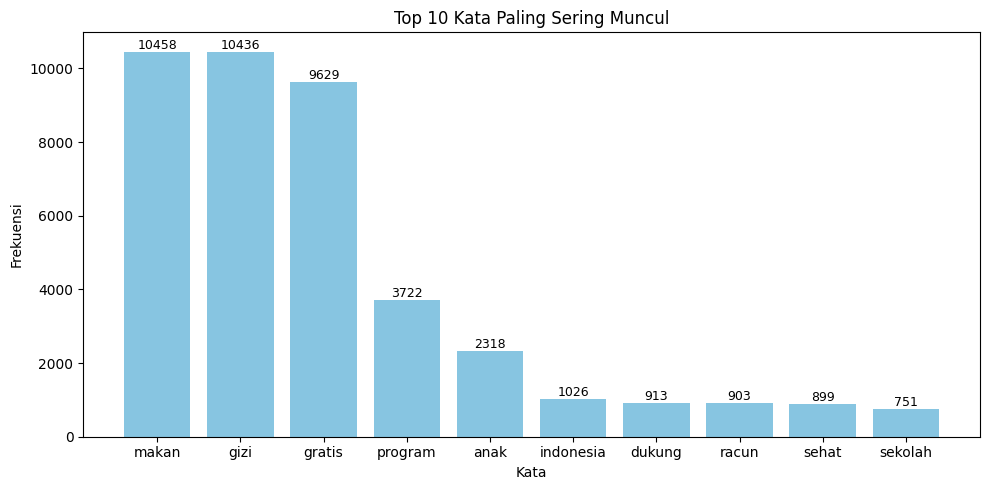

In [22]:
from collections import Counter

all_tokens = [t for tokens in df['tokens_stemmed'] for t in tokens]
freq = Counter(all_tokens).most_common(10)
words, counts = zip(*freq)

plt.figure(figsize=(10,5))
bars = plt.bar(
    words,
    counts,
    color='#87c5e1',
)

plt.title("Top 10 Kata Paling Sering Muncul")
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.xticks(rotation=0)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

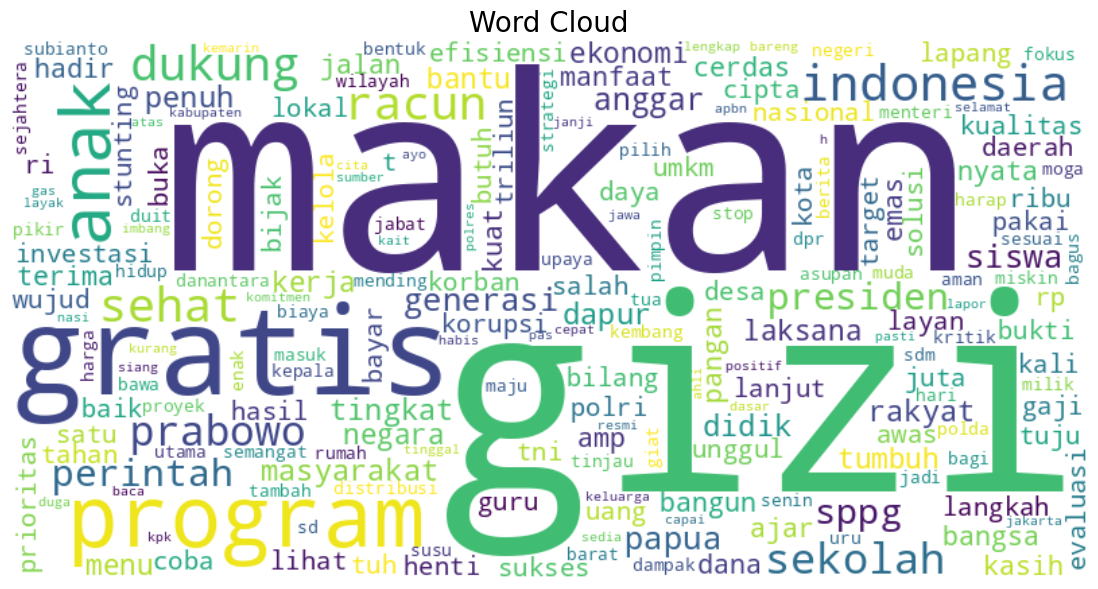

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungkan semua token yang sudah di-stem menjadi satu list
all_words = [word for tokens_list in df['tokens_stemmed'] for word in tokens_list]

# Gabungkan semua kata menjadi satu string
text_all = " ".join(all_words)

# Buat objek WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False  # Hindari gabungan kata dua
).generate(text_all)

# Tampilkan WordCloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud", fontsize=20)
plt.show()

## Analisis Sentimen (SVM)

In [24]:
df_labeled = pd.read_csv('/content/drive/MyDrive/skripsi HUHU/4. Data Penelitian/Dataset/data_labeled_preproc_new.csv')

display(df_labeled)

,full_text,label,clean_text,clean_text_norm,tokens,tokens_no_stop,tokens_stemmed
0,"@iweng01 @akunbarublek @ignasbowo Tpi tujuan awal dari makan siang gratis ini kan untuk perbaikan gizi dan pencegahan stunting? Pencegahan stunting ini jls g efektif krn prio nya di anak sekolah, lalu gmn kl misal anak itu ga suka lauknya/pnya alergi? Anak kecil kbnykn picky eater jd berkemungkinan besar g dimkn",negative,tpi tujuan awal dari makan siang gratis ini kan untuk perbaikan gizi dan pencegahan stunting pencegahan stunting ini jls g efektif krn prio nya di anak sekolah lalu gmn kl misal anak itu ga suka lauknya pnya alergi anak kecil kbnykn picky eater jd berkemungkinan besar g dimkn,tapi tujuan awal dari makan siang gratis ini kan untuk perbaikan gizi dan pencegahan stunting pencegahan stunting ini jls tidak efektif karena prio nya di anak sekolah lalu bagaimana kalo misal anak itu tidak suka lauknya punya alergi anak kecil kbnykn picky eater jadi berkemungkinan besar tidak dimkn,"['tapi', 'tujuan', 'awal', 'dari', 'makan', 'siang', 'gratis', 'ini', 'kan', 'untuk', 'perbaikan', 'gizi', 'dan', 'pencegahan', 'stunting', 'pencegahan', 'stunting', 'ini', 'jls', 'tidak', 'efektif', 'karena', 'prio', 'nya', 'di', 'anak', 'sekolah', 'lalu', 'bagaimana', 'kalo', 'misal', 'anak', 'itu', 'tidak', 'suka', 'lauknya', 'punya', 'alergi', 'anak', 'kecil', 'kbnykn', 'picky', 'eater', 'jadi', 'berkemungkinan', 'besar', 'tidak', 'dimkn']","['tujuan', 'makan', 'siang', 'gratis', 'perbaikan', 'gizi', 'pencegahan', 'stunting', 'pencegahan', 'stunting', 'jls', 'efektif', 'prio', 'anak', 'sekolah', 'anak', 'suka', 'lauknya', 'alergi', 'anak', 'kbnykn', 'picky', 'eater', 'berkemungkinan', 'dimkn']","['tuju', 'makan', 'siang', 'gratis', 'baik', 'gizi', 'cegah', 'stunting', 'cegah', 'stunting', 'jls', 'efektif', 'prio', 'anak', 'sekolah', 'anak', 'suka', 'lauk', 'alergi', 'anak', 'kbnykn', 'picky', 'eater', 'mungkin', 'dimkn']"
1,BI Dukung Program Makan Siang Gratis Asalkan Tak Ganggu Stabilitas Keuangan https://t.co/OtJJgdUUOX,positive,bi dukung program makan siang gratis asalkan tak ganggu stabilitas keuangan,bi dukung program makan siang gratis asalkan tak ganggu stabilitas keuangan,"['bi', 'dukung', 'program', 'makan', 'siang', 'gratis', 'asalkan', 'tak', 'ganggu', 'stabilitas', 'keuangan']","['bi', 'dukung', 'program', 'makan', 'siang', 'gratis', 'ganggu', 'stabilitas', 'keuangan']","['bi', 'dukung', 'program', 'makan', 'siang', 'gratis', 'ganggu', 'stabilitas', 'uang']"
2,"@RizkiDimasDwij @masgah_ @Ipaahu La iya dana bos aja dikorup, apalagi ada proyek makan siang gratis Sama aja kalau sdm sekolahnya sudah korup ya selamanya korup, korupnya tetep sama cuma beda proyek, kalau dulu korupnya proyek beli buku kalau skrng proyek beli susu",negative,la iya dana bos aja dikorup apalagi ada proyek makan siang gratis sama aja kalau sdm sekolahnya sudah korup ya selamanya korup korupnya tetep sama cuma beda proyek kalau dulu korupnya proyek beli buku kalau skrng proyek beli susu,lah iya dana bos saja dikorup apalagi ada proyek makan siang gratis sama saja kalau sdm sekolahnya sudah korup ya selamanya korup korupnya tetap sama cuma beda proyek kalau dulu korupnya proyek beli buku kalau sekarang proyek beli susu,"['lah', 'iya', 'dana', 'bos', 'saja', 'dikorup', 'apalagi', 'ada', 'proyek', 'makan', 'siang', 'gratis', 'sama', 'saja', 'kalau', 'sdm', 'sekolahnya', 'sudah', 'korup', 'ya', 'selamanya', 'korup', 'korupnya', 'tetap', 'sama', 'cuma', 'beda', 'proyek', 'kalau', 'dulu', 'korupnya', 'proyek', 'beli', 'buku', 'kalau', 'sekarang', 'proyek', 'beli', 'susu']","['dana', 'bos', 'dikorup', 'proyek', 'makan', 'siang', 'gratis', 'sdm', 'sekolahnya', 'korup', 'korup', 'korupnya', 'beda', 'proyek', 'korupnya', 'proyek', 'beli', 'buku', 'proyek', 'beli', 'susu']","['dana', 'bos', 'korup', 'proyek', 'makan', 'siang', 'gratis', 'sdm', 'sekolah', 'korup', 'korup', 'korup', 'beda', 'proyek', 'korup', 'proyek', 'beli', 'buku', 'proyek', 'beli', 'susu']"
3,@OposisiCerdas Ya di

In [25]:
import ast

df_labeled['tokens_stemmed'] = df_labeled['tokens_stemmed'].apply(ast.literal_eval)
df_labeled['final_text'] = df_labeled['tokens_stemmed'].apply(lambda x: ' '.join(x))

df_labeled['final_text'].head()

,final_text
0,tuju makan siang gratis baik gizi cegah stunting cegah stunting jls efektif prio anak sekolah anak suka lauk alergi anak kbnykn picky eater mungkin dimkn
1,bi dukung program makan siang gratis ganggu stabilitas uang
2,dana bos korup proyek makan siang gratis sdm sekolah korup korup korup beda proyek korup proyek beli buku proyek beli susu
3,gaji makan siang gratis
4,stunting solusi makan siang gratis selesai akar masalah tambah alur


In [26]:
def run_svm_classification(data, text_column, label_column, kernel='linear', scenario_name="Scenario"):

    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.model_selection import train_test_split
    from sklearn.svm import SVC
    from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
    import matplotlib.pyplot as plt
    import numpy as np

    print(f"\n===== {scenario_name} =====")

    # Ekstraksi Fitur TF-IDF
    tfidf = TfidfVectorizer(max_features=5000)
    X = tfidf.fit_transform(data[text_column])
    y = data[label_column]

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # SVM
    model = SVC(kernel=kernel, class_weight='balanced')
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    labels = np.unique(y_test)

    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion Matrix - {scenario_name}")
    plt.colorbar()

    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(len(cm)):
        for j in range(len(cm)):
            plt.text(j, i, cm[i][j], ha='center', va='center')

    plt.tight_layout()
    plt.show()

    return model, tfidf, acc, X_train, X_test

### **1. Ekstraksi Fitur TF-IDF**

In [27]:
# This cell is now part of the `run_svm_classification` function in the cell above.
# No action needed here.

### **2. Splitting Data**

In [28]:
# This cell is now part of the `run_svm_classification` function in the cell above.
# No action needed here.

### **3. Training Model SVM**

In [29]:
# This cell is now part of the `run_svm_classification` function in the cell above.
# No action needed here.

### **4. Evaluasi Model**

In [30]:
# This cell is now part of the `run_svm_classification` function in the cell above.
# No action needed here.

In [31]:
# This cell is now part of the `run_svm_classification` function in the cell above.
# No action needed here.

### **Contoh Output**

In [32]:
print(df_labeled['final_text'].head(10))

0    tuju makan siang gratis baik gizi cegah stunting cegah stunting jls efektif prio anak sekolah anak suka lauk alergi anak kbnykn picky eater mungkin dimkn
1                                                                                                  bi dukung program makan siang gratis ganggu stabilitas uang
2                                   dana bos korup proyek makan siang gratis sdm sekolah korup korup korup beda proyek korup proyek beli buku proyek beli susu
3                                                                                                                                      gaji makan siang gratis
4                                                                                          stunting solusi makan siang gratis selesai akar masalah tambah alur
5                                                                                   baca program target makan siang gratis anak sekolah putus sekolah otomatis
6                                             

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer # Added import

# Initialize and fit TF-IDF Vectorizer locally within this cell
tfidf_local = TfidfVectorizer(max_features=5000) # Using max_features as defined in run_svm_classification
X = tfidf_local.fit_transform(df_labeled['final_text'])
y = df_labeled['label']   # ganti sesuai nama kolom labelmu

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# buat model SVM
model = SVC(kernel='rbf')

# training model
model.fit(X_train, y_train)

# prediksi
y_pred = model.predict(X_test)

print(y_pred[:10])

['negative' 'negative' 'negative' 'negative' 'negative' 'negative'
 'negative' 'negative' 'negative' 'negative']


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer # Added import

# Initialize and fit TF-IDF Vectorizer to create X
tfidf_matrix_local = TfidfVectorizer(max_features=5000)
X = tfidf_matrix_local.fit_transform(df_labeled['final_text'])
y = df_labeled['label']   # sesuaikan nama kolom labelmu

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train_linear.shape)
print(X_test_linear.shape)

(524, 1949)
(132, 1949)


In [39]:
y_pred = model.predict(X_test)
print(y_pred[:10])

['negative' 'negative' 'negative' 'negative' 'negative' 'negative'
 'negative' 'negative' 'negative' 'negative']


### **Running per-Skenario**


===== SVM Linear =====
Accuracy: 0.7651515151515151

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.88      0.86       105
    positive       0.41      0.33      0.37        27

    accuracy                           0.77       132
   macro avg       0.62      0.60      0.61       132
weighted avg       0.75      0.77      0.76       132



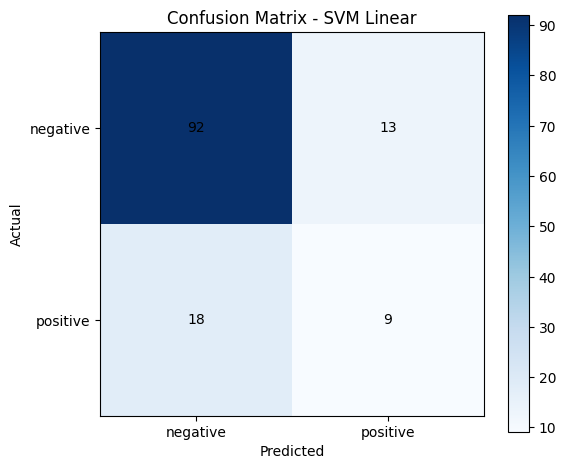

In [41]:
model_linear, tfidf_linear, acc_linear, X_train_linear, X_test_linear = run_svm_classification(
    data=df_labeled,
    text_column="final_text",
    label_column="label",
    kernel='linear',
    scenario_name="SVM Linear"
)


===== SVM RBF =====
Accuracy: 0.803030303030303

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.97      0.89       105
    positive       0.57      0.15      0.24        27

    accuracy                           0.80       132
   macro avg       0.69      0.56      0.56       132
weighted avg       0.77      0.80      0.75       132



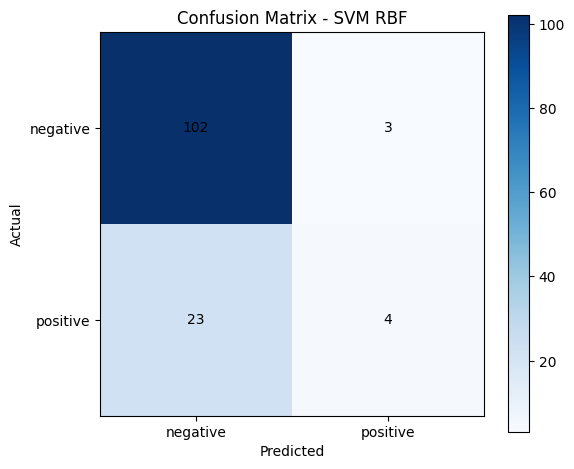

In [42]:
model_rbf, tfidf_rbf, acc_rbf, X_train_rbf, X_test_rbf = run_svm_classification(
    data=df_labeled,
    text_column="final_text",
    label_column="label",
    kernel='rbf',
    scenario_name="SVM RBF"
)


===== SVM Polynomial =====
Accuracy: 0.803030303030303

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.99      0.89       105
    positive       0.67      0.07      0.13        27

    accuracy                           0.80       132
   macro avg       0.74      0.53      0.51       132
weighted avg       0.78      0.80      0.73       132



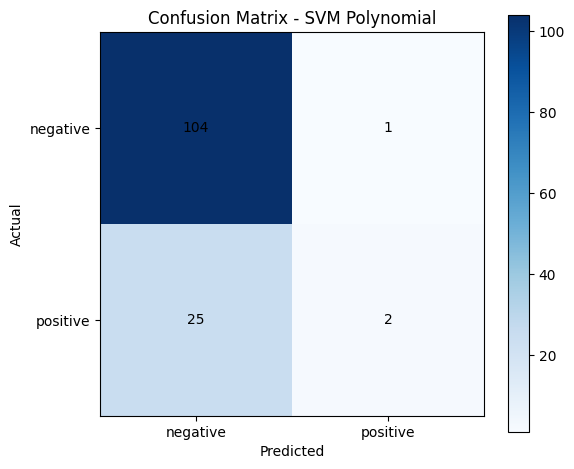

In [43]:
model_poly, tfidf_poly, acc_poly, X_train_poly, X_test_poly = run_svm_classification(
    data=df_labeled,
    text_column="final_text",
    label_column="label",
    kernel='poly',
    scenario_name="SVM Polynomial"
)

### **Perbandingan Kernel**

In [44]:
print("\n=== Perbandingan Kernel SVM ===")
print("Linear     :", acc_linear)
print("RBF        :", acc_rbf)
print("Polynomial :", acc_poly)


=== Perbandingan Kernel SVM ===
Linear     : 0.7651515151515151
RBF        : 0.803030303030303
Polynomial : 0.803030303030303


In [45]:
import ast

df['final_text'] = df['tokens_stemmed'].apply(lambda x: ' '.join(x))

In [46]:
display(df['final_text'])

,final_text
0,makan gizi gratis umkm sebar suara anak anak dapat manfaat utuh
1,hadir umkm makan gizi gratis solusi efektif sehat
2,makan gizi gratis umkm bantu masyarakat akses pangan kualitas jaga sehat
3,umkm keroyokan makan gizi gratis masyarakat sehat jangkau
4,salut maju makan gizi gratis berkat libat umkm andil
...,...
8098,anak racun makan gizi gratis diam diam gilir ads kerja komentar komentar mutu btw ente tuju ormas dibubarin manfaat urus sertifikasi halal pakai cuan
8099,buzzer makan gizi gratis aksi gaes
8100,upaya jaga kualitas aman konsumsi masyarakat bhabinkamtibmas lurah bantar gebang aiptu zainal musyarifin laksana giat kece menu makan makan gizi gratis dapur makan gizi gratis bangun persada sppg bantargebang selasa
8101,tolak makan gizi gratis laku erti murid sekolah by guru bimbel


In [47]:
X_9000 = tfidf_rbf.transform(df['final_text'])

y_pred_9000 = model_rbf.predict(X_9000)

df['sentiment'] = y_pred_9000

In [48]:
df['sentiment'].value_counts()

,count
sentiment,
negative,6481
positive,1622


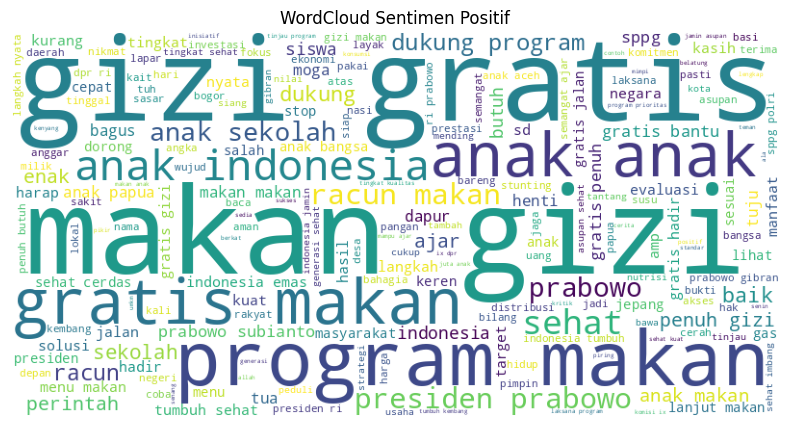

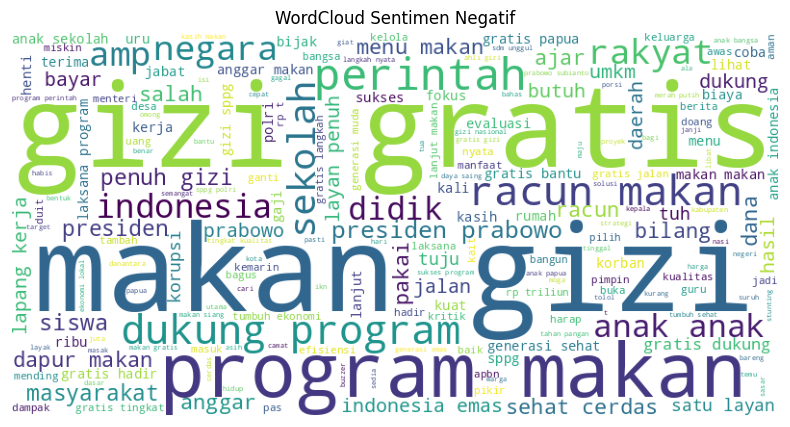

In [49]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# POSITIF
pos_words = [w for tokens in df[df['sentiment']=='positive']['tokens_stemmed'] for w in tokens]
text_pos = " ".join(pos_words)

wc_pos = WordCloud(width=800, height=400, background_color='white').generate(text_pos)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos)
plt.axis('off')
plt.title("WordCloud Sentimen Positif")
plt.show()


# NEGATIF
neg_words = [w for tokens in df[df['sentiment']=='negative']['tokens_stemmed'] for w in tokens]
text_neg = " ".join(neg_words)

wc_neg = WordCloud(width=800, height=400, background_color='white').generate(text_neg)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg)
plt.axis('off')
plt.title("WordCloud Sentimen Negatif")
plt.show()

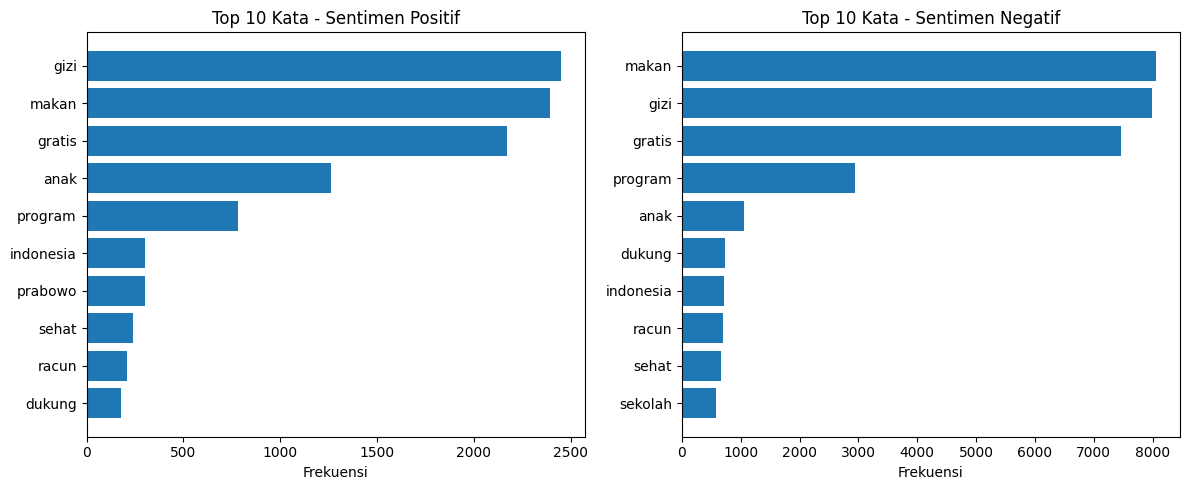

In [50]:
from collections import Counter
import matplotlib.pyplot as plt

# ======================
# AMBIL DATA
# ======================
pos_words = [w for tokens in df[df['sentiment']=='positive']['tokens_stemmed'] for w in tokens]
neg_words = [w for tokens in df[df['sentiment']=='negative']['tokens_stemmed'] for w in tokens]

# ======================
# HITUNG TOP 10
# ======================
top10_pos = Counter(pos_words).most_common(10)
top10_neg = Counter(neg_words).most_common(10)

# pisahin kata & jumlah
words_pos, counts_pos = zip(*top10_pos)
words_neg, counts_neg = zip(*top10_neg)

# ======================
# VISUALISASI GABUNGAN
# ======================
plt.figure(figsize=(12,5))

# POSITIF
plt.subplot(1,2,1)
plt.barh(words_pos, counts_pos)
plt.gca().invert_yaxis()
plt.title("Top 10 Kata - Sentimen Positif")
plt.xlabel("Frekuensi")

# NEGATIF
plt.subplot(1,2,2)
plt.barh(words_neg, counts_neg)
plt.gca().invert_yaxis()
plt.title("Top 10 Kata - Sentimen Negatif")
plt.xlabel("Frekuensi")

plt.tight_layout()
plt.show()

In [51]:
data_words = df['tokens_stemmed'].tolist()

print(f"Total dokumen: {len(data_words)}")
print(f"Contoh dokumen pertama: {data_words[0][:10]}")

Total dokumen: 8103
Contoh dokumen pertama: ['makan', 'gizi', 'gratis', 'umkm', 'sebar', 'suara', 'anak', 'anak', 'dapat', 'manfaat']


## Pemodelan Topik (LDA)

### **1. Membuat Bigram & Trigram**

In [52]:
from gensim.models.phrases import Phrases, Phraser

# Build bigram model
bigram = Phrases(data_words, min_count=3, threshold=5, delimiter='_')
bigram_mod = Phraser(bigram)

# Build trigram model
trigram = Phrases(bigram[data_words], threshold=5, delimiter='_')
trigram_mod = Phraser(trigram)

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

data_bigrams = make_bigrams(data_words)
data_trigrams = make_trigrams(data_words)

print("Contoh setelah bigram:", data_bigrams[0][:10])
print("Contoh setelah trigram:", data_trigrams[0][:10])

Contoh setelah bigram: ['makan_gizi', 'gratis', 'umkm', 'sebar', 'suara', 'anak_anak', 'dapat', 'manfaat', 'utuh']
Contoh setelah trigram: ['makan_gizi_gratis', 'umkm', 'sebar', 'suara', 'anak_anak', 'dapat', 'manfaat', 'utuh']


### **2. Dictionary & Corpus**

In [53]:
id2word = corpora.Dictionary(data_trigrams)
bow_corpus = [id2word.doc2bow(text) for text in data_trigrams]

### **3. Pemodelan Topik**

In [54]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [55]:
# Fungsi untuk mencari jumlah topik LDA yang terbaik
def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):
    coherence_values = []
    model_list = []

    for num_topics in range(start, limit, step):
        model = gensim.models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            update_every=1,
            chunksize=100,
            passes=10,
            alpha='auto',
            eta='auto',
            per_word_topics=False
        )

        model_list.append(model)

        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence_score = coherence_model.get_coherence()
        coherence_values.append(coherence_score)

    return model_list, coherence_values

In [56]:
# Set parameter
start_topics = 2
limit_topics = 7
step = 1

# Menghitung Coherence
model_list, coherence_values = compute_coherence_values(
    dictionary=id2word,
    corpus=bow_corpus,
    texts=data_trigrams,
    start=start_topics,
    limit=limit_topics,
    step=step
)

### **4. Evaluasi Model**

--- Coherence Scores by Number of Topics ---
 num_topics  coherence
          2   0.315097
          3   0.239044
          4   0.362995
          5   0.369289
          6   0.366903

--- Optimal Configuration ---
Optimal number of topics: 5
Coherence score: 0.3693


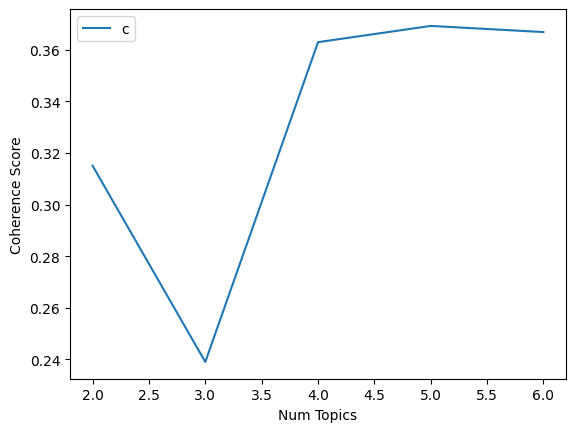

In [57]:
results_df = pd.DataFrame({
    'num_topics': range(start_topics, limit_topics, step),
    'coherence': coherence_values,
})

print("--- Coherence Scores by Number of Topics ---")
print(results_df.to_string(index=False))

# Find optimal number of topics
optimal_idx = coherence_values.index(max(coherence_values))
optimal_topics = range(start_topics, limit_topics, step)[optimal_idx]
optimal_coherence = max(coherence_values)

print("\n--- Optimal Configuration ---")
print(f"Optimal number of topics: {optimal_topics}")
print(f"Coherence score: {optimal_coherence:.4f}")

# Visualisasi grafik coherence
x = range(start_topics, limit_topics, step)

plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence Score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [58]:
lda_model = gensim.models.ldamodel.LdaModel(
    corpus=bow_corpus,
    id2word=id2word,
    num_topics=optimal_topics,
    random_state=42,
    update_every=1,
    chunksize=100,
    passes=10,
    alpha='auto',
    eta='auto',
    per_word_topics=False
)

### **5. Interpretasi & Visualisasi**

In [59]:
# Menentukan jumlah topik
model_topics = lda_model.show_topics(formatted=False)
pprint(lda_model.print_topics(num_words=20))

[(0,
  '0.039*"program" + 0.026*"lbp" + 0.025*"kualitas" + 0.020*"laku" + '
  '0.018*"dana_makan_gizi" + 0.018*"upaya" + 0.017*"tolak_makan_gizi" + '
  '0.017*"lawan" + 0.017*"menkeu" + 0.016*"berani" + 0.016*"narasi" + '
  '0.016*"siswa" + 0.016*"teknologi" + 0.012*"sesat" + 0.012*"nasihat" + '
  '0.011*"henti" + 0.010*"digitalisasi" + 0.009*"daerah" + '
  '0.008*"presiden_prabowo" + 0.008*"kerja"'),
 (1,
  '0.210*"makan_gizi_gratis" + 0.039*"perintah" + 0.024*"racun" + 0.020*"guru" '
  '+ 0.018*"investasi" + 0.015*"amp" + 0.014*"bhabinkamtibmas" + '
  '0.012*"prabowo" + 0.011*"jalan" + 0.009*"didik" + 0.008*"negara" + '
  '0.005*"dana" + 0.005*"makan_racun" + 0.005*"kritik" + 0.005*"layak" + '
  '0.004*"wajib" + 0.004*"kurang" + 0.004*"jamin" + 0.004*"anggar_makan_gizi" '
  '+ 0.004*"sumber"'),
 (2,
  '0.205*"gratis" + 0.069*"program_makan_gizi" + 0.023*"gratis_makan_gizi" + '
  '0.022*"anak" + 0.020*"anak_anak" + 0.018*"masyarakat" + 0.016*"sehat" + '
  '0.016*"gizi" + 0.014*"jaga" 

In [60]:
# Visualisasi topik
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, bow_corpus, id2word)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.339970  0.066119       1        1  27.155163
4     -0.160150  0.276908       2        1  22.645749
1     -0.066464 -0.221204       3        1  21.906649
0     -0.062075 -0.085115       4        1  15.504024
3     -0.051281 -0.036708       5        1  12.788414, topic_info=                     Term         Freq        Total Category  logprob  loglift
34                 gratis  4558.000000  4558.000000  Default  30.0000  30.0000
2       makan_gizi_gratis  3773.000000  3773.000000  Default  29.0000  29.0000
36     program_makan_gizi  1532.000000  1532.000000  Default  28.0000  28.0000
184                 makan   805.000000   805.000000  Default  27.0000  27.0000
451              perintah   708.000000   708.000000  Default  26.0000  26.0000
...                   ...          ...          ...      ...      ...      ...
11088              bantar    50.575465   154.357323   Topic5  -5.3324   0.9408
11089              gebang    50.575465   154.357323   Topic5  -5.3324   0.9408
11090          musyarifin    50.575465   154.357323   Topic5  -5.3324   0.9408
11091             persada    50.575465   154.357323   Topic5  -5.3324   0.9408
11092              zainal    50.575465   154.357323   Topic5  -5.3324   0.9408

[197 rows x 6 columns], token_table=       Topic      Freq       Term
term                             
1544       3  0.993475  ahli_gizi
5273       1  0.004822      aiptu
5273       2  0.988591      aiptu
5273       3  0.004822      aiptu
5273       5  0.004822      aiptu
...      ...       ...        ...
11092      1  0.161962     zainal
11092      2  0.252661     zainal
11092      3  0.136048     zainal
11092      4  0.123091     zainal
11092      5  0.330402     zainal

[222 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 5, 2, 1, 4])

### **6. Penentuan Topik Dominan**

In [61]:
# 1. Prediksi topik untuk setiap dokumen
doc_topics = []

for doc in bow_corpus:
    topics = lda_model.get_document_topics(doc)
    doc_topics.append(topics)

# 2. Ambil topik dominan & probabilitasnya
dominant_topics = []
topic_probabilities = []

for topics in doc_topics:
    if len(topics) > 0:
        sorted_topics = sorted(topics, key=lambda x: x[1], reverse=True)
        dominant_topic = sorted_topics[0][0]
        topic_prob = sorted_topics[0][1]
    else:
        dominant_topic = -1
        topic_prob = 0.0

    dominant_topics.append(dominant_topic)
    topic_probabilities.append(topic_prob)

# 3. Masukkan ke dataframe
df['dominant_topic'] = dominant_topics
df['topic_probability'] = topic_probabilities

# 4. Mapping ke label (FIX SESUAI HASIL LDA)
topic_label_map = {
    0: "Kualitas Program",
    1: "Implementasi Program",
    2: "Manfaat Program",
    3: "Kualitas Makanan",
    4: "Fasilitas Program"
}

df['Aspect_Label'] = df['dominant_topic'].map(topic_label_map)

# 5. Lihat hasil
display(df[['full_text', 'Aspect_Label', 'sentiment', 'topic_probability']])

,full_text,Aspect_Label,sentiment,topic_probability
0,Dengan MBG UMKM sebar suara agar anak-anak dapatkan manfaat seutuhnya #UMKMDukungMBG https://t.co/5DFTlg6UDK,Implementasi Program,negative,0.340927
1,Kehadiran UMKM buat MBG jadi solusi efektif membuat sehat #UMKMDukungMBG https://t.co/HDHUt3Essy,Manfaat Program,negative,0.391888
2,Dengan MBG UMKM membantu masyarakat mendapatkan akses pangan berkualitas dan terus menjaga kesehatan #UMKMDukungMBG https://t.co/FUciDjcfon,Manfaat Program,negative,0.487218
3,UMKM keroyokan banget di MBG demi masyarakat lebih sehat dan terjangkau #UMKMDukungMBG https://t.co/VwjRil59uT,Manfaat Program,negative,0.369372
4,Salut buat kemajuan MBG berkat keterlibatan penuh UMKM yang turut andil #UMKMDukungMBG https://t.co/mWf9If2xaQ,Manfaat Program,negative,0.352673
...,...,...,...,...
8098,@Julhan_Htbarat @MUIPusat Nah itu dia anak keracunan MBG pada diem kasus ini juga pada diem eh giliran ads kerja dikomentari mana komentarnya gak bermutu lagi. Eh btw ente setuju gak kalau ormas itu dibubarin? Gak ada manfaatnya sama sekali kecuali urusan sertifikasi halal dan itu pake cuan lo,Fasilitas Program,negative,0.249023
8099,Buzzer MBG beraksi gaes,Fasilitas Program,negative,0.288911
8100,Dalam upaya menjaga kualitas dan keamanan konsumsi masyarakat Bhabinkamtibmas Kelurahan Bantar Gebang Aiptu Zainal Musyarifin melaksanakan kegiatan pengecekan menu makanan MBG di Dapur MBG Bangun Persada SPPG Bantargebang Selasa(7/10/25). https://t.co/KwbAZzsyAV,Fasilitas Program,negative,0.297355
8101,Penolakan MBG tidak bisa di lakukan tetapi bisa di berikan pengertian terhadap murid di sekolah. By : guru bimbel,Manfaat Program,negative,0.318068


In [62]:
dist = df.groupby(['Aspect_Label', 'sentiment']).size().unstack(fill_value=0)
print(dist)

sentiment             negative  positive
Aspect_Label                            
Fasilitas Program         1343       187
Implementasi Program      1515       412
Kualitas Makanan           250        14
Kualitas Program           386        21
Manfaat Program           2987       988


In [63]:
print("UNIQUE SENTIMENT:", df['sentiment'].unique())
print("UNIQUE TOPIC:", df['Aspect_Label'].unique())
print("JUMLAH DATA:", len(df))

for topic in df['Aspect_Label'].dropna().unique():
    print(f"\n===== TOPIK: {topic} =====")

    subset = df[df['Aspect_Label'] == topic]

    print("\n--- Sentimen Positif ---")
    positif = subset[subset['sentiment'] == 'positive'][['full_text', 'topic_probability']].head(5)

    for i, row in positif.iterrows():
        print(f"- {row['full_text']}")
        print(f"  (Probabilitas: {row['topic_probability']:.4f})\n")

    print("\n--- Sentimen Negatif ---")
    negatif = subset[subset['sentiment'] == 'negative'][['full_text', 'topic_probability']].head(15)

    for i, row in negatif.iterrows():
        print(f"- {row['full_text']}")
        print(f"  (Probabilitas: {row['topic_probability']:.4f})\n")

UNIQUE SENTIMENT: ['negative' 'positive']
UNIQUE TOPIC: ['Implementasi Program' 'Manfaat Program' 'Kualitas Program'
 'Fasilitas Program' 'Kualitas Makanan']
JUMLAH DATA: 8103

===== TOPIK: Implementasi Program =====

--- Sentimen Positif ---
- Padahal selama gue kuliah di gizi aja matkul paling basic yg dipelajari ya sosioantro ekspektasi gue pun ini makan bergizi gratis menunya menyesuaikan kultur makan di tiap daerahnya. Tapi ternyata ekspektasi gue ketinggian 
  (Probabilitas: 0.2329)

- Makan bergizi gratis yang seharusnya
  (Probabilitas: 0.2751)

- Asyik makan bergizi gratis. https://t.co/TRwl2fYEtb
  (Probabilitas: 0.2683)

- Progam andalan Prabowo-Gibran Makan Bergizi Gratis udah dimulai Senin lalu. Ada yang senang dan ada juga sejumlah kritik dari orang tua serta siswa. Penasaran? Tonton lengkapnya ya dalam Cerita Lensa. #makansiangbergizi #mbg #makangratis #zulkiflihasan #prabowo #gibran https://t.co/YEscrbv1hv
  (Probabilitas: 0.3485)

- Sudah 80 Tahun Jalani Makan Bergizi 

## Analisis Hasil Keseluruhan

In [64]:
# Tabel distribusi aspek
aspect_distribution = (
    df['Aspect_Label']
    .value_counts()
    .reset_index()
)

aspect_distribution.columns = ['Aspect', 'Jumlah Data']

aspect_distribution

,Aspect,Jumlah Data
0,Manfaat Program,3975
1,Implementasi Program,1927
2,Fasilitas Program,1530
3,Kualitas Program,407
4,Kualitas Makanan,264


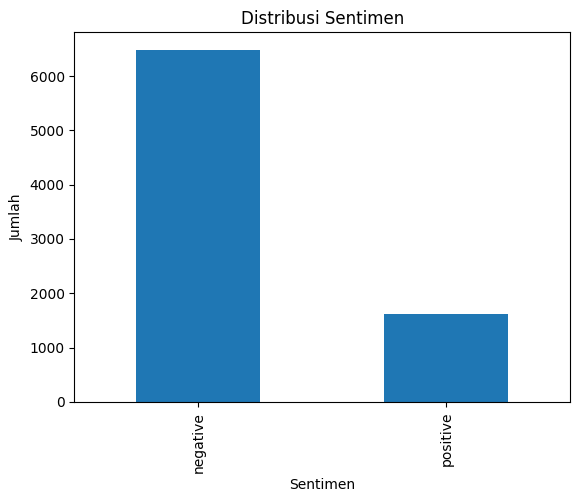

In [65]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Distribusi Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")
plt.show()

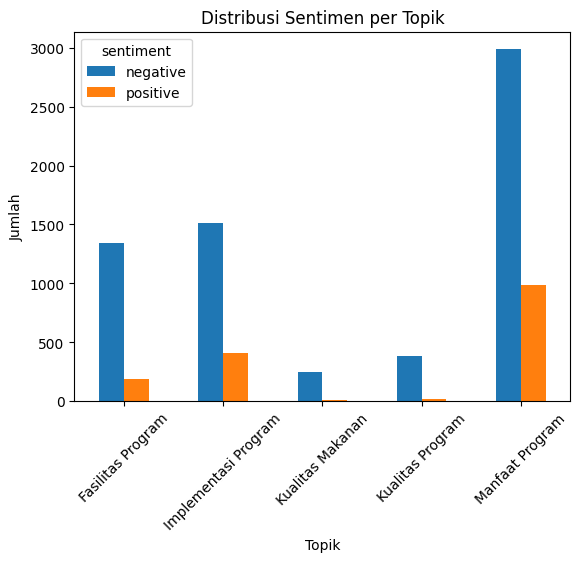

In [66]:
df.groupby(['Aspect_Label','sentiment']).size().unstack().plot(kind='bar')
plt.title("Distribusi Sentimen per Topik")
plt.xlabel("Topik")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.show()

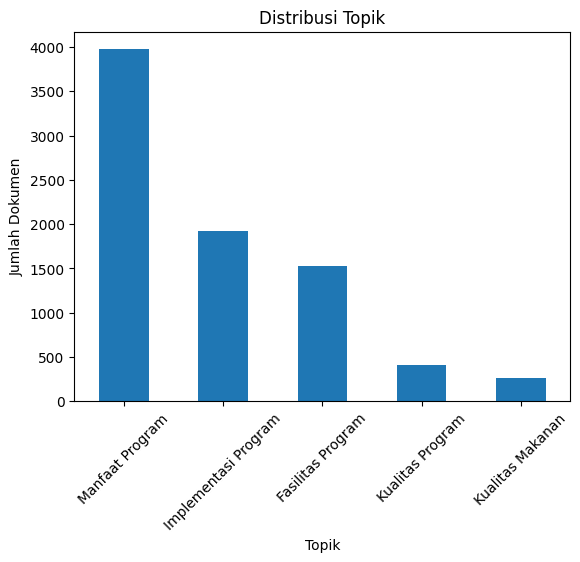

In [67]:
df['Aspect_Label'].value_counts().plot(kind='bar')
plt.title("Distribusi Topik")
plt.xlabel("Topik")
plt.ylabel("Jumlah Dokumen")
plt.xticks(rotation=45)
plt.show()

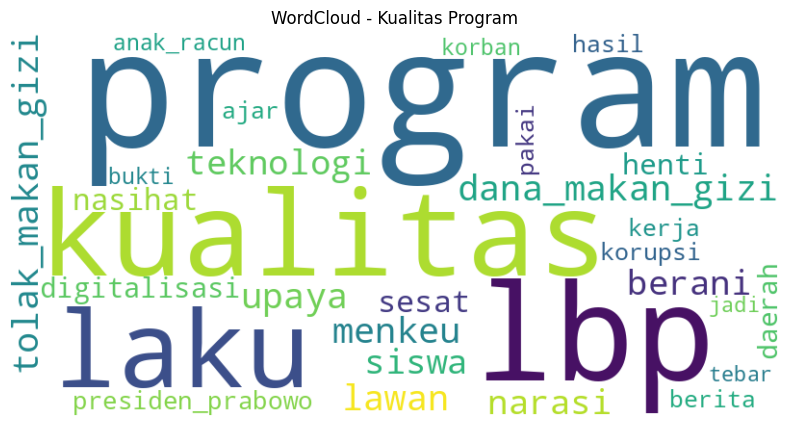

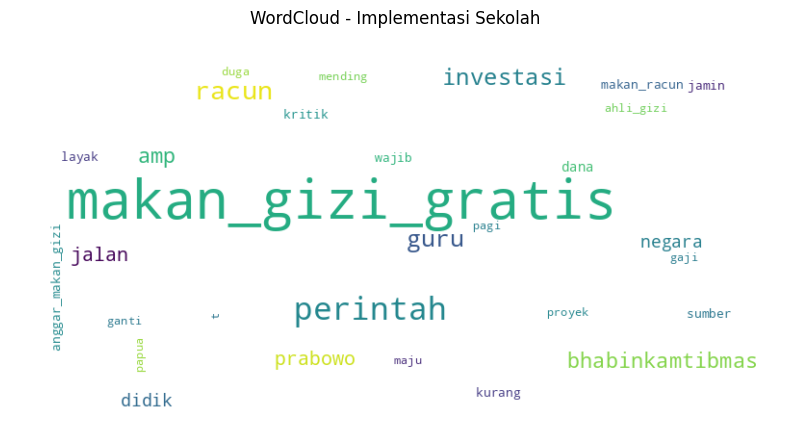

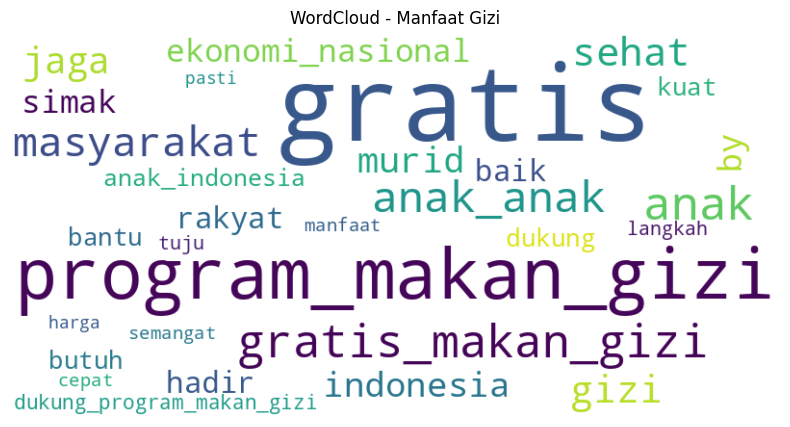

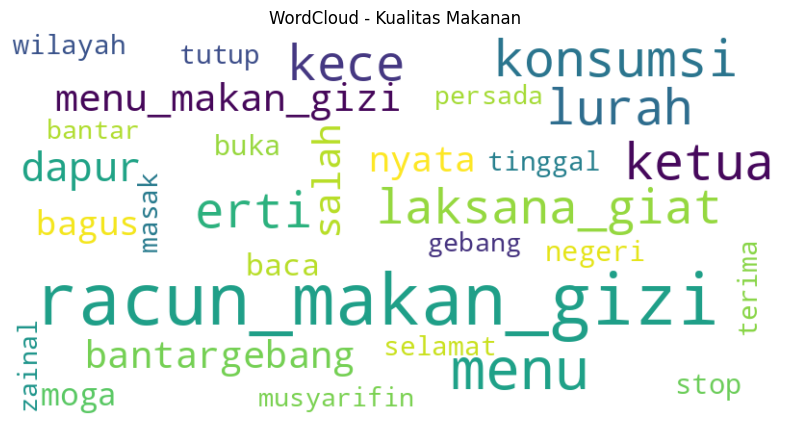

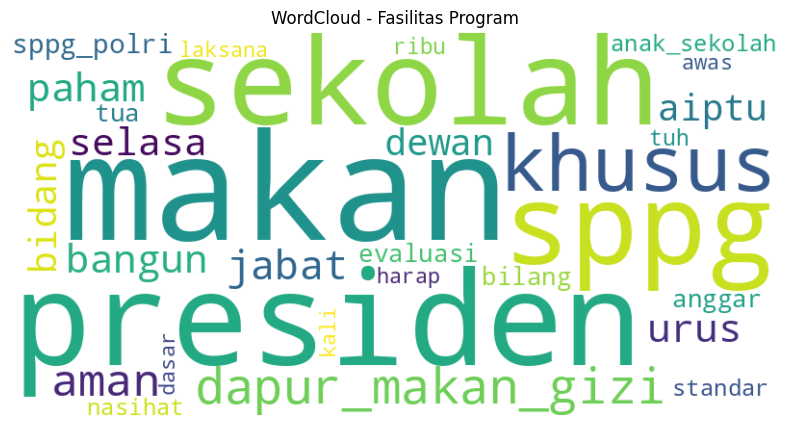

In [68]:
topic_names = {
    0: "Kualitas Program",
    1: "Implementasi Sekolah",
    2: "Manfaat Gizi",
    3: "Kualitas Makanan",
    4: "Fasilitas Program"
}

from wordcloud import WordCloud
import matplotlib.pyplot as plt

for topic_num in range(5):
    words = dict(lda_model.show_topic(topic_num, 30))

    # 🔥 FIX: scale biar ga kosong
    words = {k: v*1000 for k, v in words.items()}

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=30
    ).generate_from_frequencies(words)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - {topic_names[topic_num]}")
    plt.show()

## GUI

In [85]:
import joblib
import pickle

# Save model SVM + vectorizer
joblib.dump(model_rbf, 'model_rbf.pkl')
joblib.dump(tfidf_rbf, 'tfidf_rbf.pkl')

# Save model LDA + dictionary
lda_model.save('lda_model')
id2word.save('lda_dictionary')

print("✅ Semua model berhasil disimpan!")
import os
print("File yang tersimpan:", [f for f in os.listdir() if not f.startswith('.')])

✅ Semua model berhasil disimpan!
File yang tersimpan: ['lda_model.id2word', 'lda_dictionary', 'tfidf_rbf.pkl', 'model_rbf.pkl', 'lda_model', 'drive', 'lda_model.state', 'lda_model.expElogbeta.npy', 'sample_data']


In [86]:
from google.colab import files

files.download('model_rbf.pkl')
files.download('tfidf_rbf.pkl')
files.download('lda_model')
files.download('lda_model.state')
files.download('lda_model.id2word')
files.download('lda_model.expElogbeta.npy')
files.download('lda_dictionary')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
import os
print([f for f in os.listdir() if any(x in f for x in ['lda', 'model', 'tfidf', 'pkl'])])

['lda_model.id2word', 'lda_dictionary', 'tfidf_rbf.pkl', 'model_rbf.pkl', 'lda_model', 'lda_model.state', 'lda_model.expElogbeta.npy']


In [84]:
# Task
import gradio as gr
import pandas as pd
import joblib
import re
import gensim # Import gensim
import gensim.corpora as corpora # Import for Dictionary

# =========================
# LOAD MODEL
# =========================
model = joblib.load("model_rbf.pkl")
tfidf = joblib.load("tfidf_rbf.pkl")
lda_model = gensim.models.ldamodel.LdaModel.load('lda_model') # Corrected loading
dictionary = gensim.corpora.Dictionary.load('lda_dictionary') # Corrected loading

# =========================
# PREPROCESSING
# =========================
def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.strip()

# =========================
# ANALISIS SENTIMEN
# =========================
def analisis_sentimen(text):
    clean_text = preprocess(text)

    vector = tfidf.transform([clean_text])

    prediksi = model.predict(vector)[0]

    # ambil kata dominan tfidf
    feature_names = tfidf.get_feature_names_out()
    tfidf_scores = vector.toarray()[0]

    top_indices = tfidf_scores.argsort()[-5:][::-1]
    top_words = [feature_names[i] for i in top_indices if tfidf_scores[i] > 0]

    alasan = f"Tweet mengandung kata dominan: {', '.join(top_words)}"

    return prediksi, alasan

# =========================
# PEMODELAN TOPIK
# =========================
def analisis_topik(text):
    clean_text = preprocess(text)

    tokens = clean_text.split()

    bow = dictionary.doc2bow(tokens)

    topics = lda_model.get_document_topics(bow)

    if len(topics) == 0:
        return "Topik tidak ditemukan", "-", "Teks terlalu pendek"

    top_topic = max(topics, key=lambda x: x[1])[0]

    keywords = lda_model.show_topic(top_topic, topn=5)
    keyword_list = [word for word, _ in keywords]

    nama_topik = f"Topik {top_topic+1}"

    analisis = f"Tweet membahas: {', '.join(keyword_list)}"

    return nama_topik, ", ".join(keyword_list), analisis

# =========================
# INPUT LINK TWEET
# =========================
def ambil_teks_dari_link(link):
    return f"Simulasi teks dari link:\n{link}"

# =========================
# MAIN FUNCTION
# =========================
def proses_data(mode, input_type, text_input, tweet_link, file_csv):

    hasil_sentimen = ""
    hasil_topik = ""
    hasil_analisis = ""

    # =====================
    # AMBIL INPUT
    # =====================
    if input_type == "Tulis Teks":
        text = text_input

    elif input_type == "Link Tweet":
        text = ambil_teks_dari_link(tweet_link)

    elif input_type == "Upload CSV":

        if file_csv is None:
            return "Upload file CSV dulu", "", ""

        df = pd.read_csv(file_csv.name)

        if "tweet" not in df.columns:
            return "CSV harus punya kolom 'tweet'", "", ""

        results = []

        for t in df["tweet"]:

            row_result = {}

            if mode in ["Sentimen", "Keduanya"]:
                sentimen, alasan = analisis_sentimen(str(t))
                row_result["sentimen"] = sentimen
                row_result["alasan"] = alasan

            if mode in ["Topik", "Keduanya"]:
                topic, keywords, analisis = analisis_topik(str(t))
                row_result["topik"] = topic
                row_result["keywords"] = keywords
                row_result["analisis"] = analisis

            results.append(row_result)

        hasil_df = pd.DataFrame(results)

        return hasil_df, "", ""

    else:
        text = ""

    # =====================
    # ANALISIS SENTIMEN
    # =====================
    if mode in ["Sentimen", "Keduanya"]:

        sentimen, alasan = analisis_sentimen(text)

        hasil_sentimen = f"""
Sentimen: {sentimen}

Alasan:
{alasan}
"""

    # =====================
    # ANALISIS TOPIK
    # =====================
    if mode in ["Topik", "Keduanya"]:

        topic, keywords, analisis = analisis_topik(text)

        hasil_topik = f"""
Topik: {topic}

Kata Dominan:
{keywords}
"""

        hasil_analisis = analisis

    return hasil_sentimen, hasil_topik, hasil_analisis

# =========================
# GRADIO UI
# =========================
with gr.Blocks() as demo:

    gr.Markdown("# Analisis Sentimen & Pemodelan Topik MBG")

    mode = gr.Radio(
        ["Sentimen", "Topik", "Keduanya"],
        label="Pilih Analisis",
        value="Keduanya"
    )

    input_type = gr.Radio(
        ["Tulis Teks", "Link Tweet", "Upload CSV"],
        label="Pilih Input",
        value="Tulis Teks"
    )

    text_input = gr.Textbox(
        label="Masukkan Teks Tweet",
        lines=5
    )

    tweet_link = gr.Textbox(
        label="Masukkan Link Tweet"
    )

    file_csv = gr.File(
        label="Upload CSV"
    )

    btn = gr.Button("Analisis")

    output1 = gr.Textbox(label="Hasil Sentimen")
    output2 = gr.Textbox(label="Hasil Topik")
    output3 = gr.Textbox(label="Analisis Singkat")

    btn.click(
        fn=proses_data,
        inputs=[
            mode,
            input_type,
            text_input,
            tweet_link,
            file_csv
        ],
        outputs=[
            output1,
            output2,
            output3
        ]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3c08312483a95bd4ac.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
